# Fold 0 Baseline vs Fine-Tuned Inference Comparison

Runs the same fold_0 validation patients through the baseline and long fine-tuned checkpoints, exports Slicer-ready NIfTI files, and saves clean per-patient comparison figures.


## 1. Mount Azure Data


In [ ]:
# %pip install azureml-dataset-runtime
from azureml.core import Workspace, Dataset
from pathlib import Path
import os

# 1. Connect to your workspace (v1 syntax)
ws = Workspace(
    subscription_id="ab211f7b-463f-4833-9605-d260e596a35a",
    resource_group="73da10b4-5dff-54e2-db0d-3a1fab882485",
    workspace_name="73da10b45dff54e2db0d3a1fab882485"
)

# 2. Get your datastore
datastore = ws.datastores["73da10b45dff54e2db0d3a1fab882485"]

# 3. Create a dataset reference to your root NIFTI folder
nifti_dataset = Dataset.File.from_files(path=(datastore, 'NIFTI/DATA_REGISTERED_FIXED_LATE'))

# 4. Download the dataset locally instead of mounting it
local_mount_path = Path("./nifti_data").resolve()
local_mount_path.mkdir(parents=True, exist_ok=True)
# nifti_dataset.download(target_path=str(local_mount_path), overwrite=True)

# 5. Get the actual local OS path
local_mount_path = str(local_mount_path)
print(f"Data successfully downloaded to: {local_mount_path}")

# Verify by listing the folders inside the download
print(os.listdir(local_mount_path)[:5])


Data successfully downloaded to: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/nifti_data
['TAVI_098', 'TAVI_054', 'TAVI_266', 'TAVI_096', 'TAVI_062']


## 2. Configuration

The default setup compares the two fold_0 checkpoints and processes every patient assigned to fold_0 in `data/cv_splits.csv`. Set `CASE_NAMES` or `MAX_PATIENTS` when you want a quick subset run.


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

FOLD_INDEX = 0
DATA_ROOT = Path(globals().get("local_mount_path", PROJECT_ROOT / "notebooks" / "nifti_data"))
SPLIT_CSV = PROJECT_ROOT / "data" / "cv_splits.csv"

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "notebooks"
    / "output"
    / "named-outputs"
    / "output_model"
    / f"fold_{FOLD_INDEX}"
)
MODEL_SPECS = [
    {
        "name": "baseline",
        "label": "Baseline",
        "path": CHECKPOINT_DIR / "best_metric_model_baseline.pth",
        "segmentation_filename": "segmentation_baseline.nii.gz",
    },
    {
        "name": "finetuned",
        "label": "Fine-tuned",
        "path": CHECKPOINT_DIR / "best_metric_model_finetuned.pth",
        "segmentation_filename": "segmentation_finetuned.nii.gz",
    },
]

COMPARISON_OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "fold0_baseline_vs_finetuned"
COMPARISON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# None = all fold_0 validation patients from SPLIT_CSV.
# Example subset: CASE_NAMES = ["TAVI_149", "TAVI_104"]
CASE_NAMES = None
MAX_PATIENTS = None

SLICE_PERCENTAGES = [13, 16, 19, 22, 25, 27, 29, 31, 34, 37, 40, 43, 47, 50, 53, 56, 59, 62, 65, 68, 71, 74, 77, 80]
TARGET_SPACING = (1.0, 1.0, 1.0)
ROI_SIZE = (96, 96, 96)
SW_BATCH_SIZE = 4
OVERLAP = 0.5
SW_MODE = "gaussian"  # reduces patch-border artefacts

# The training script evaluated EMA weights when present, so this keeps inference consistent.
USE_EMA_WEIGHTS = True
NUM_WORKERS = 0

# Figures are saved for every patient. To avoid a very large notebook output,
# only the first N patients are displayed inline.
DISPLAY_FIRST_N_PATIENTS = 2


## 3. Imports


In [3]:
# %pip install torch
%pip install nibabel
%pip install monai


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import inspect
import re
import shutil
import sys
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

try:
    from scipy.ndimage import binary_erosion, generate_binary_structure
    from scipy.spatial import cKDTree
except ImportError:
    binary_erosion = None
    generate_binary_structure = None
    cKDTree = None

from monai.networks.nets import SegResNet
from monai.inferers import sliding_window_inference
from monai.data import Dataset, DataLoader, MetaTensor, decollate_batch
from monai.transforms import (
    AsDiscreted, Compose, CropForegroundd, EnsureChannelFirstd,
    Invertd, KeepLargestConnectedComponent, KeepLargestConnectedComponentd,
    LoadImaged, Orientationd, ScaleIntensityRanged, Spacingd,
)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


def autocast_context():
    if device.type == "cuda":
        return torch.amp.autocast("cuda")
    if device.type == "mps":
        return torch.amp.autocast("mps")
    return nullcontext()


print(f"Using device: {device}")


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Using device: mps


## 4. Fold 0 Case Selection


In [5]:
PATIENT_PATTERN = re.compile(r"^TAVI_\d+$")


def find_valid_cases(input_dir):
    input_dir = Path(input_dir)
    if not input_dir.exists():
        raise FileNotFoundError(f"Data root does not exist: {input_dir}")

    cases = []
    for folder in sorted(input_dir.iterdir()):
        if not (folder.is_dir() and PATIENT_PATTERN.match(folder.name)):
            continue
        img = folder / "CT_LATE.nii.gz"
        lbl = folder / "registration_mask.nii.gz"
        if img.exists() and lbl.exists():
            cases.append({"image": str(img), "label": str(lbl), "name": folder.name})
    return cases


def select_cases(cases, split_csv, fold_index, case_names=None, max_patients=None):
    case_by_name = {case["name"]: case for case in cases}

    if case_names:
        selected_names = list(case_names)
    else:
        split_csv = Path(split_csv)
        if not split_csv.exists():
            raise FileNotFoundError(f"CV split file does not exist: {split_csv}")
        split_df = pd.read_csv(split_csv)
        fold_rows = split_df[split_df["fold"].astype(int) == int(fold_index)]
        selected_names = fold_rows["patient_id"].astype(str).tolist()

    missing = [name for name in selected_names if name not in case_by_name]
    if missing:
        print(f"Skipping {len(missing)} fold_{fold_index} patients not found under {DATA_ROOT}:")
        print(", ".join(missing[:20]) + (" ..." if len(missing) > 20 else ""))

    selected = [case_by_name[name] for name in selected_names if name in case_by_name]
    if max_patients is not None:
        selected = selected[: int(max_patients)]
    if not selected:
        raise ValueError("No valid patients selected for inference.")
    return selected


all_cases = find_valid_cases(DATA_ROOT)
selected_cases = select_cases(all_cases, SPLIT_CSV, FOLD_INDEX, CASE_NAMES, MAX_PATIENTS)

print(f"Data root         : {DATA_ROOT}")
print(f"CV split file     : {SPLIT_CSV}")
print(f"Fold selected     : fold_{FOLD_INDEX}")
print(f"Patients selected : {len(selected_cases)}")
print("First patients    :", ", ".join(case["name"] for case in selected_cases[:10]))


Data root         : /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/nifti_data
CV split file     : /Users/ricca/Desktop/Health_Informatics_Internship_2026/data/cv_splits.csv
Fold selected     : fold_0
Patients selected : 46
First patients    : TAVI_149, TAVI_104, TAVI_177, TAVI_367, TAVI_302, TAVI_082, TAVI_135, TAVI_075, TAVI_203, TAVI_188


## 5. Checkpoints


In [6]:
def verify_model_specs(model_specs):
    missing = [spec for spec in model_specs if not Path(spec["path"]).exists()]
    if missing:
        raise FileNotFoundError(
            "Missing comparison checkpoints:\n"
            + "\n".join(str(spec["path"]) for spec in missing)
        )

    for spec in model_specs:
        path = Path(spec["path"])
        print(f"{spec['label']:>10}: {path} ({path.stat().st_size / (1024**2):.1f} MB)")
    return model_specs


MODEL_SPECS = verify_model_specs(MODEL_SPECS)
print(f"Output directory: {COMPARISON_OUTPUT_DIR}")


  Baseline: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/named-outputs/output_model/fold_0/best_metric_model_baseline.pth (71.9 MB)
Fine-tuned: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/named-outputs/output_model/fold_0/best_metric_model_finetuned.pth (71.9 MB)
Output directory: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned


## 6. Transforms


In [7]:
infer_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    CropForegroundd(keys=["image"], source_key="image"),
    Spacingd(keys=["image"], pixdim=TARGET_SPACING, mode=("bilinear",)),
    ScaleIntensityRanged(
        keys=["image"], a_min=-100.0, a_max=400.0,
        b_min=0.0, b_max=1.0, clip=True,
    ),
])

val_transforms_with_label = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    Spacingd(keys=["image", "label"], pixdim=TARGET_SPACING, mode=("bilinear", "nearest")),
    ScaleIntensityRanged(
        keys=["image"], a_min=-100.0, a_max=400.0,
        b_min=0.0, b_max=1.0, clip=True,
    ),
])

post_transforms = Compose([
    Invertd(
        keys="pred",
        transform=infer_transforms,
        orig_keys="image",
        meta_keys="pred_meta_dict",
        orig_meta_keys="image_meta_dict",
        meta_key_postfix="meta_dict",
        nearest_interp=False,
        to_tensor=True,
    ),
    AsDiscreted(keys="pred", argmax=True),
    KeepLargestConnectedComponentd(
        keys="pred",
        applied_labels=[1],
        is_onehot=False,
        independent=True,
        connectivity=1,
        num_components=1,
    ),
])

keep_largest_cc_preprocessed = KeepLargestConnectedComponent(
    applied_labels=[1],
    is_onehot=False,
    independent=True,
    connectivity=1,
    num_components=1,
)


monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


## 7. Model Loading and Inference Helpers


In [8]:
MODEL_CONFIG = {
    "spatial_dims": 3,
    "in_channels": 1,
    "out_channels": 2,
    "init_filters": 16,
    "blocks_down": [1, 2, 2, 4],
    "blocks_up": [1, 1, 1],
}


def as_numpy(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def build_model():
    return SegResNet(**MODEL_CONFIG)


def torch_load_checkpoint(path):
    load_kwargs = {"map_location": "cpu"}
    try:
        if "weights_only" in inspect.signature(torch.load).parameters:
            load_kwargs["weights_only"] = False
    except (TypeError, ValueError):
        pass

    # Some older checkpoints reference numpy._core during unpickling.
    if hasattr(np, "core"):
        sys.modules["numpy._core"] = np.core
        sys.modules["numpy._core.multiarray"] = np.core.multiarray

    return torch.load(path, **load_kwargs)


def normalize_state_dict_keys(state_dict):
    return {key[7:] if key.startswith("module.") else key: value for key, value in state_dict.items()}


def load_checkpoint_to_model(model, checkpoint_path, use_ema_weights=True):
    checkpoint = torch_load_checkpoint(checkpoint_path)
    state_key = "model_state_dict"

    if isinstance(checkpoint, dict):
        if use_ema_weights and checkpoint.get("ema_model_state_dict"):
            state_key = "ema_model_state_dict"
        state_dict = checkpoint.get(state_key, checkpoint)
    else:
        state_dict = checkpoint

    model.load_state_dict(normalize_state_dict_keys(state_dict))
    model.to(device)
    model.eval()

    metadata = {
        "checkpoint": str(checkpoint_path),
        "state_key": state_key,
        "step": checkpoint.get("step") if isinstance(checkpoint, dict) else None,
        "best_dice": checkpoint.get("best_dice") if isinstance(checkpoint, dict) else None,
        "loss_name": checkpoint.get("loss_name") if isinstance(checkpoint, dict) else None,
    }
    return metadata


def load_comparison_models(model_specs):
    models = {}
    metadata = {}
    for spec in model_specs:
        model = build_model()
        meta = load_checkpoint_to_model(model, spec["path"], USE_EMA_WEIGHTS)
        models[spec["name"]] = {**spec, "model": model}
        metadata[spec["name"]] = meta
        dice_text = "n/a" if meta["best_dice"] is None else f"{float(meta['best_dice']):.4f}"
        print(f"Loaded {spec['label']} from {meta['state_key']} | checkpoint best Dice: {dice_text}")
    return models, metadata


def prepare_patient_batch(patient_case):
    ds = Dataset(data=[patient_case], transform=infer_transforms)
    loader = DataLoader(ds, batch_size=1, num_workers=NUM_WORKERS)
    return next(iter(loader))


def load_preprocessed_patient(patient_case):
    sample = val_transforms_with_label(patient_case)
    ct_vol = as_numpy(sample["image"])[0].astype(np.float32)
    gt_mask = as_numpy(sample["label"])[0].astype(np.uint8)
    return ct_vol, gt_mask


def meta_to_plain_dict(meta):
    if meta is None:
        return {}
    if not isinstance(meta, dict):
        meta = dict(meta)
    plain = {}
    for key, value in meta.items():
        plain[key] = as_numpy(value) if isinstance(value, torch.Tensor) else value
    return plain


def affine_from_meta(*metas):
    for meta in metas:
        meta = meta_to_plain_dict(meta)
        affine = meta.get("affine")
        if affine is not None:
            affine = as_numpy(affine)
            if affine.ndim == 3 and affine.shape[0] == 1:
                affine = affine[0]
            return np.asarray(affine, dtype=np.float64)
    return np.eye(4, dtype=np.float64)


def squeeze_mask(mask):
    mask = as_numpy(mask)
    if mask.ndim == 4 and mask.shape[0] == 1:
        mask = mask[0]
    elif mask.ndim == 4 and mask.shape[0] > 1:
        mask = np.argmax(mask, axis=0)
    return mask.astype(np.uint8)


def save_mask_like_reference(mask, reference_path, output_path):
    reference_img = nib.load(str(reference_path))
    mask_np = squeeze_mask(mask)
    if mask_np.shape != reference_img.shape:
        raise ValueError(
            f"Cannot save {output_path}: mask shape {mask_np.shape} "
            f"does not match reference shape {reference_img.shape}"
        )

    header = reference_img.header.copy()
    header.set_data_dtype(np.uint8)
    header.set_slope_inter(1, 0)

    output_img = nib.Nifti1Image(mask_np.astype(np.uint8), reference_img.affine, header=header)
    qform_code = int(reference_img.header["qform_code"]) or 1
    sform_code = int(reference_img.header["sform_code"]) or 1
    output_img.set_qform(reference_img.affine, qform_code)
    output_img.set_sform(reference_img.affine, sform_code)
    nib.save(output_img, str(output_path))
    return mask_np


def save_prediction_in_original_space(probs, batch, output_path, reference_path):
    src_meta = batch["image"].meta if hasattr(batch["image"], "meta") else batch.get("image_meta_dict")
    predictions = MetaTensor(probs.detach().cpu(), meta=src_meta)
    batch_data = {"image": batch["image"], "pred": predictions}

    for item in decollate_batch(batch_data):
        if "image_meta_dict" not in item:
            item["image_meta_dict"] = batch["image"].meta if hasattr(batch["image"], "meta") else src_meta
        if "pred_meta_dict" not in item:
            item["pred_meta_dict"] = dict(meta_to_plain_dict(item["image_meta_dict"]))

        item["pred_meta_dict"] = meta_to_plain_dict(item.get("pred_meta_dict"))
        item["image_meta_dict"] = meta_to_plain_dict(item.get("image_meta_dict"))
        item = post_transforms(item)

        pred_np = squeeze_mask(item["pred"])
        return save_mask_like_reference(pred_np, reference_path, output_path)

    raise RuntimeError("No prediction item produced after decollation.")


def copy_slicer_inputs(patient_case, patient_dir):
    copies = {
        "volume_CT_LATE.nii.gz": patient_case["image"],
        "ground_truth_mask.nii.gz": patient_case["label"],
    }
    for filename, source in copies.items():
        destination = patient_dir / filename
        if not destination.exists():
            shutil.copy2(source, destination)


def release_device_cache():
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps" and hasattr(torch.mps, "empty_cache"):
        torch.mps.empty_cache()


def run_models_for_patient(patient_case, models, patient_dir):
    batch = prepare_patient_batch(patient_case)
    inputs = batch["image"].to(device)
    results = {}

    with torch.inference_mode():
        for model_name, model_payload in models.items():
            print(f"    {model_payload['label']} inference ...")
            with autocast_context():
                logits = sliding_window_inference(
                    inputs,
                    ROI_SIZE,
                    SW_BATCH_SIZE,
                    model_payload["model"],
                    overlap=OVERLAP,
                    mode=SW_MODE,
                )
                probs = torch.softmax(logits, dim=1)

            pred_mask_raw = torch.argmax(probs, dim=1).detach().cpu().numpy()[0].astype(np.uint8)
            pred_mask_preprocessed = as_numpy(
                keep_largest_cc_preprocessed(torch.as_tensor(pred_mask_raw[None, ...], dtype=torch.uint8))
            )[0].astype(np.uint8)
            pred_original_path = patient_dir / model_payload["segmentation_filename"]
            pred_mask_original = save_prediction_in_original_space(
                probs,
                batch,
                pred_original_path,
                patient_dir / "volume_CT_LATE.nii.gz",
            )

            results[model_name] = {
                "label": model_payload["label"],
                "pred_mask": pred_mask_preprocessed,
                "pred_mask_raw": pred_mask_raw,
                "pred_original_shape": tuple(pred_mask_original.shape),
                "prediction_path": pred_original_path,
            }
            del logits, probs
            release_device_cache()

    return results


## 8. Metrics and Visualization Helpers


In [9]:
def dice_score_binary(pred_mask, gt_mask):
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)
    denom = pred_mask.sum() + gt_mask.sum()
    if denom == 0:
        return 1.0
    return 2.0 * np.logical_and(pred_mask, gt_mask).sum() / denom


def surface_voxels(mask):
    mask = mask.astype(bool)
    if not mask.any():
        return np.empty((0, 3), dtype=np.int32)

    if binary_erosion is not None:
        structure = generate_binary_structure(3, 1)
        eroded = binary_erosion(mask, structure=structure, border_value=0)
        return np.argwhere(mask & ~eroded)

    padded = np.pad(mask, 1, mode="constant", constant_values=False)
    interior = padded[1:-1, 1:-1, 1:-1]
    eroded = interior.copy()
    eroded &= padded[:-2, 1:-1, 1:-1]
    eroded &= padded[2:, 1:-1, 1:-1]
    eroded &= padded[1:-1, :-2, 1:-1]
    eroded &= padded[1:-1, 2:, 1:-1]
    eroded &= padded[1:-1, 1:-1, :-2]
    eroded &= padded[1:-1, 1:-1, 2:]
    return np.argwhere(interior & ~eroded)


def nearest_surface_distances(source_coords, target_coords, spacing, chunk_size=2048):
    if len(source_coords) == 0 or len(target_coords) == 0:
        return np.array([np.nan], dtype=np.float32)

    source_mm = source_coords.astype(np.float32) * spacing
    target_mm = target_coords.astype(np.float32) * spacing

    if cKDTree is not None:
        distances, _ = cKDTree(target_mm).query(source_mm, k=1)
        return distances.astype(np.float32)

    distances = []
    for start in range(0, len(source_mm), chunk_size):
        chunk = source_mm[start:start + chunk_size]
        diff = chunk[:, None, :] - target_mm[None, :, :]
        dist_sq = np.sum(diff * diff, axis=2)
        distances.append(np.sqrt(np.min(dist_sq, axis=1)))
    return np.concatenate(distances)


def segmentation_metrics(pred_mask, gt_mask, spacing):
    pred_bool = pred_mask.astype(bool)
    gt_bool = gt_mask.astype(bool)
    dice = dice_score_binary(pred_bool, gt_bool)

    if not pred_bool.any() and not gt_bool.any():
        hd95 = 0.0
        asd = 0.0
    elif not pred_bool.any() or not gt_bool.any():
        hd95 = 500.0
        asd = 500.0
    else:
        spacing_arr = np.asarray(spacing, dtype=np.float32)
        pred_surface = surface_voxels(pred_bool)
        gt_surface = surface_voxels(gt_bool)
        pred_to_gt = nearest_surface_distances(pred_surface, gt_surface, spacing_arr)
        gt_to_pred = nearest_surface_distances(gt_surface, pred_surface, spacing_arr)
        all_dist = np.concatenate([pred_to_gt, gt_to_pred])
        asd = float(np.clip(np.nan_to_num(np.nanmean(all_dist), nan=500), 0, 500))
        hd95 = float(np.clip(np.nan_to_num(np.nanpercentile(all_dist, 95), nan=500), 0, 500))

    pred_voxels = int(pred_bool.sum())
    gt_voxels = int(gt_bool.sum())
    vox_vol_mm3 = float(np.prod(spacing))

    return {
        "dice": float(dice),
        "hd95_mm": float(hd95),
        "asd_mm": float(asd),
        "gt_voxels": gt_voxels,
        "pred_voxels": pred_voxels,
        "gt_volume_ml": gt_voxels * vox_vol_mm3 / 1000.0,
        "pred_volume_ml": pred_voxels * vox_vol_mm3 / 1000.0,
        "overlap_fraction": float(np.logical_and(pred_bool, gt_bool).sum() / max(gt_voxels, 1)),
    }


def z_index_for_percent(depth, percent):
    return int(np.clip(round((float(percent) / 100.0) * (depth - 1)), 0, depth - 1))


def overlay_gt(ax, ct_slice, gt_slice, title):
    ax.imshow(ct_slice.T, cmap="gray", origin="lower", vmin=0, vmax=1)
    gt_rgba = np.zeros((*gt_slice.shape, 4), dtype=np.float32)
    gt_rgba[gt_slice > 0] = [0.0, 1.0, 0.0, 0.55]
    ax.imshow(gt_rgba.transpose(1, 0, 2), origin="lower")
    ax.set_title(title, fontsize=8)
    ax.axis("off")


def overlay_gt_pred(ax, ct_slice, gt_slice, pred_slice, title):
    ax.imshow(ct_slice.T, cmap="gray", origin="lower", vmin=0, vmax=1)

    gt_only = (gt_slice > 0) & ~(pred_slice > 0)
    pred_only = (pred_slice > 0) & ~(gt_slice > 0)
    overlap = (gt_slice > 0) & (pred_slice > 0)

    rgba = np.zeros((*gt_slice.shape, 4), dtype=np.float32)
    rgba[gt_only] = [0.0, 1.0, 0.0, 0.50]
    rgba[pred_only] = [1.0, 0.1, 0.1, 0.50]
    rgba[overlap] = [1.0, 1.0, 0.0, 0.65]

    ax.imshow(rgba.transpose(1, 0, 2), origin="lower")
    ax.set_title(title, fontsize=8)
    ax.axis("off")


def add_overlay_legend(fig):
    patches = [
        mpatches.Patch(color="green", alpha=0.6, label="Ground truth only"),
        mpatches.Patch(color="red", alpha=0.6, label="Prediction only"),
        mpatches.Patch(color="yellow", alpha=0.8, label="Overlap"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, 0.005))


def save_slice_percentage_figure(patient_id, ct_vol, gt_mask, model_results, metrics_by_model, patient_dir, show=False):
    rows = len(SLICE_PERCENTAGES)
    model_items = list(model_results.items())
    cols = 1 + len(model_items)
    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 2.25 * rows), squeeze=False)
    fig.suptitle(f"{patient_id} | Fold {FOLD_INDEX} baseline vs fine-tuned | requested axial z-percent slices", fontsize=13, fontweight="bold")

    for row, percent in enumerate(SLICE_PERCENTAGES):
        z = z_index_for_percent(ct_vol.shape[2], percent)
        overlay_gt(axes[row, 0], ct_vol[:, :, z], gt_mask[:, :, z], f"GT | {percent}% (z={z})")
        for col, (model_name, result) in enumerate(model_items, start=1):
            metric = metrics_by_model[model_name]
            title = (
                f"{result['label']} | {percent}% (z={z})\n"
                f"Dice {metric['dice']:.3f} | HD95 {metric['hd95_mm']:.1f} mm"
            )
            overlay_gt_pred(
                axes[row, col],
                ct_vol[:, :, z],
                gt_mask[:, :, z],
                result["pred_mask"][:, :, z],
                title,
            )

    add_overlay_legend(fig)
    plt.tight_layout(rect=(0, 0.025, 1, 0.985))
    figure_path = patient_dir / "slices_z_percentages_comparison.png"
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return figure_path


def centroid_slice(mask):
    coords = np.argwhere(mask > 0)
    if len(coords) == 0:
        return tuple((np.array(mask.shape) // 2).astype(int))
    return tuple(coords.mean(axis=0).astype(int))


def save_three_plane_figure(patient_id, ct_vol, gt_mask, model_results, metrics_by_model, patient_dir, show=False):
    cx, cy, cz = centroid_slice(gt_mask)
    model_items = list(model_results.items())
    fig, axes = plt.subplots(len(model_items), 3, figsize=(13, 4.3 * len(model_items)), squeeze=False)
    fig.suptitle(f"{patient_id} | centroid three-plane comparison", fontsize=13, fontweight="bold")

    for row, (model_name, result) in enumerate(model_items):
        pred_mask = result["pred_mask"]
        metric = metrics_by_model[model_name]
        planes = [
            (f"Axial z={cz}", ct_vol[:, :, cz], gt_mask[:, :, cz], pred_mask[:, :, cz]),
            (f"Coronal y={cy}", ct_vol[:, cy, :], gt_mask[:, cy, :], pred_mask[:, cy, :]),
            (f"Sagittal x={cx}", ct_vol[cx, :, :], gt_mask[cx, :, :], pred_mask[cx, :, :]),
        ]
        for col, (plane_name, ct_slice, gt_slice, pred_slice) in enumerate(planes):
            title = f"{result['label']} | {plane_name}\nDice {metric['dice']:.3f} | ASD {metric['asd_mm']:.1f} mm"
            overlay_gt_pred(axes[row, col], ct_slice, gt_slice, pred_slice, title)

    add_overlay_legend(fig)
    plt.tight_layout(rect=(0, 0.04, 1, 0.95))
    figure_path = patient_dir / "three_plane_comparison.png"
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return figure_path


## 9. Run Fold 0 Comparison and Export Per-Patient Folders


numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.


Loaded Baseline from ema_model_state_dict | checkpoint best Dice: 0.8665
Loaded Fine-tuned from ema_model_state_dict | checkpoint best Dice: 0.8648

[1/46] Processing TAVI_149
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    Baseline inference ...
    Fine-tuned inference ...


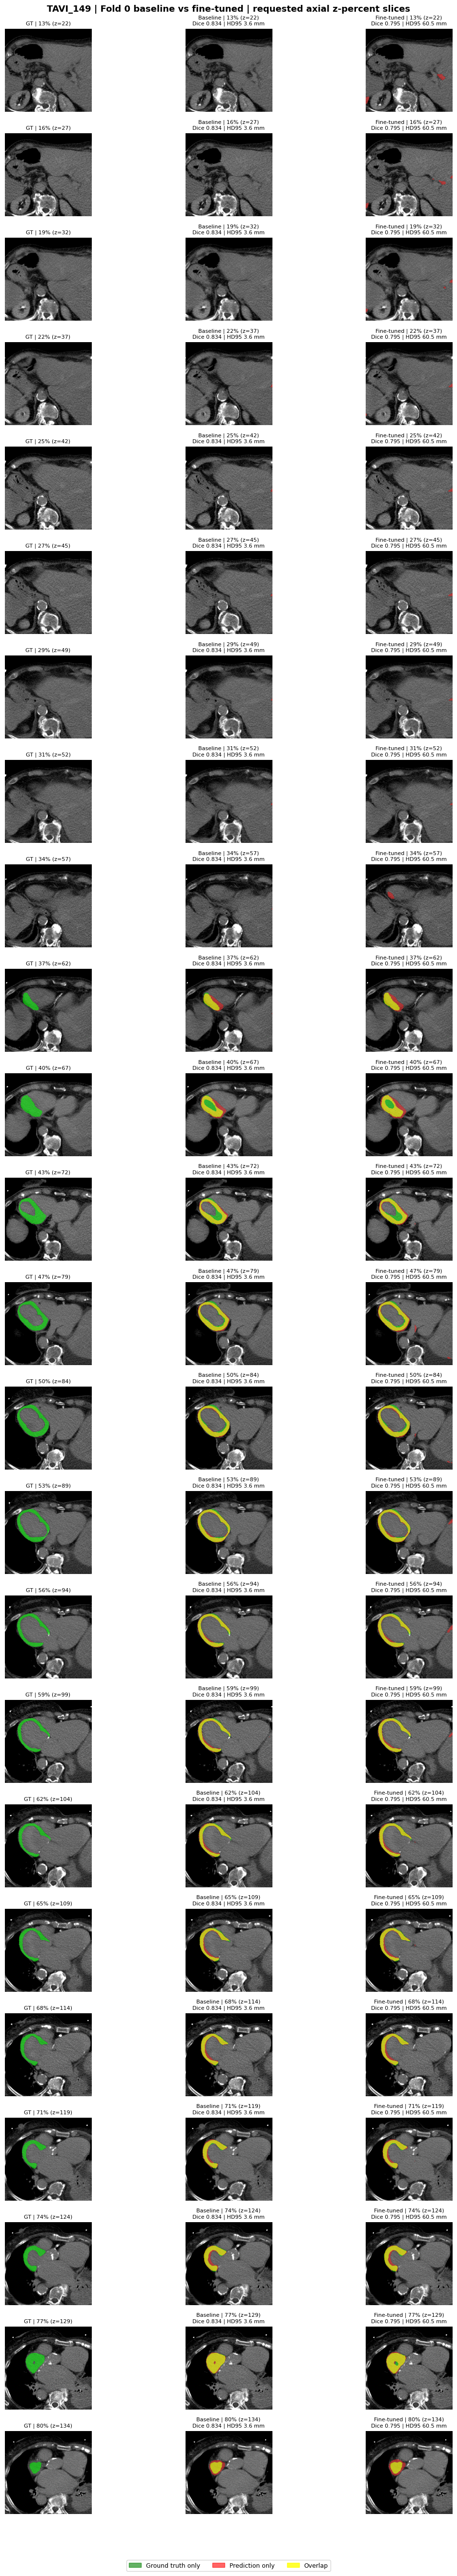

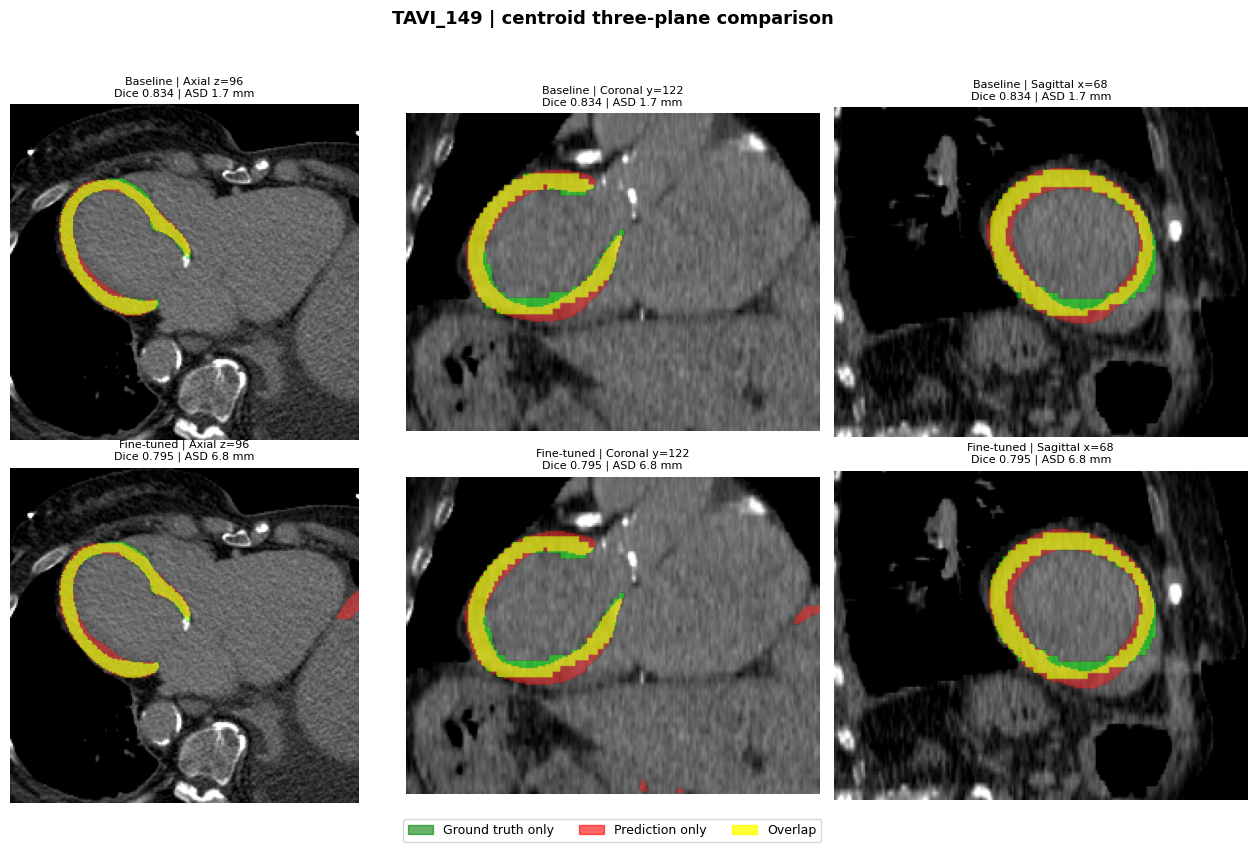

    Saved to /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_149
    Baseline: Dice 0.834 | Fine-tuned: Dice 0.795

[2/46] Processing TAVI_104
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    Baseline inference ...
    Fine-tuned inferen

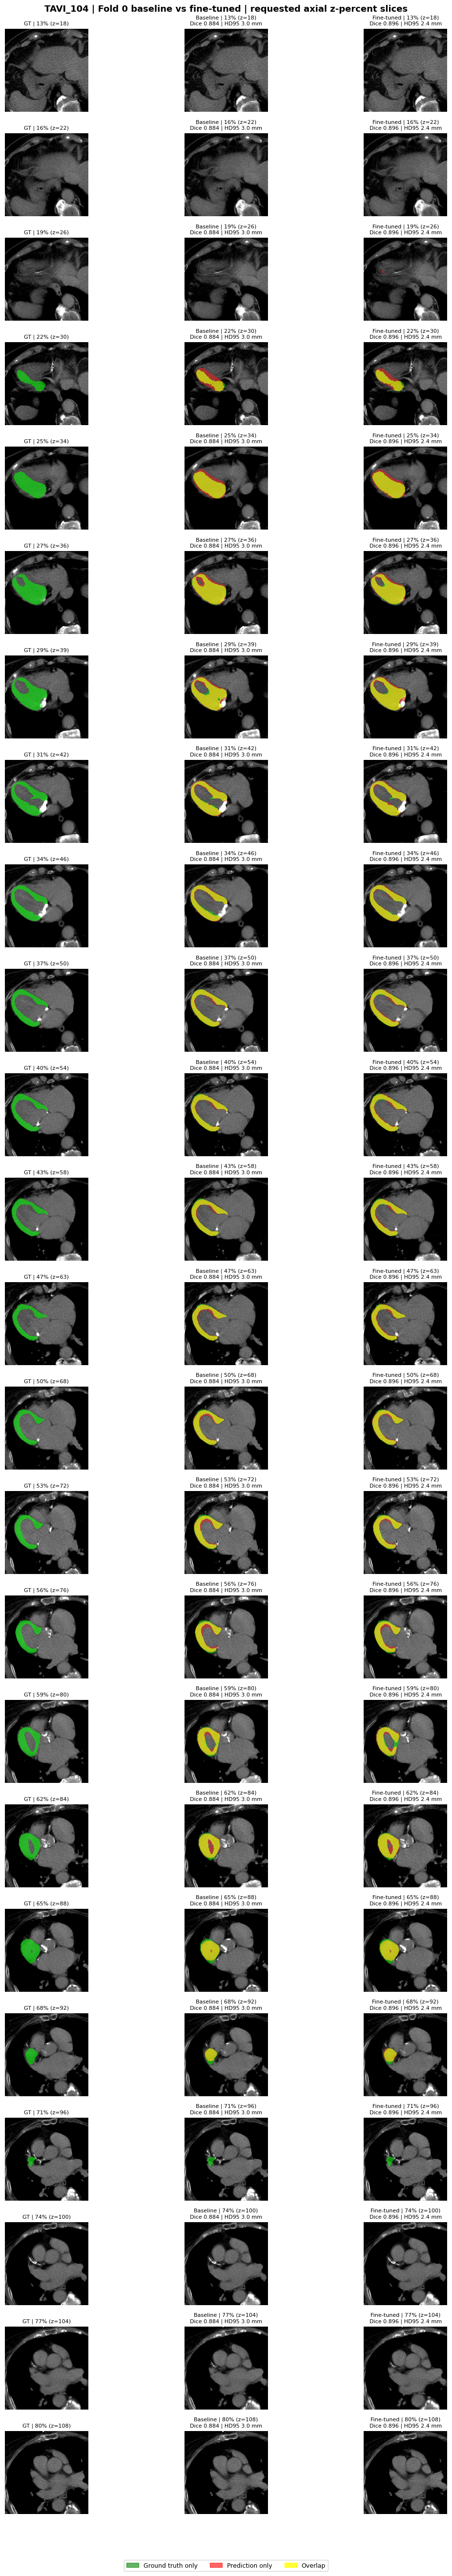

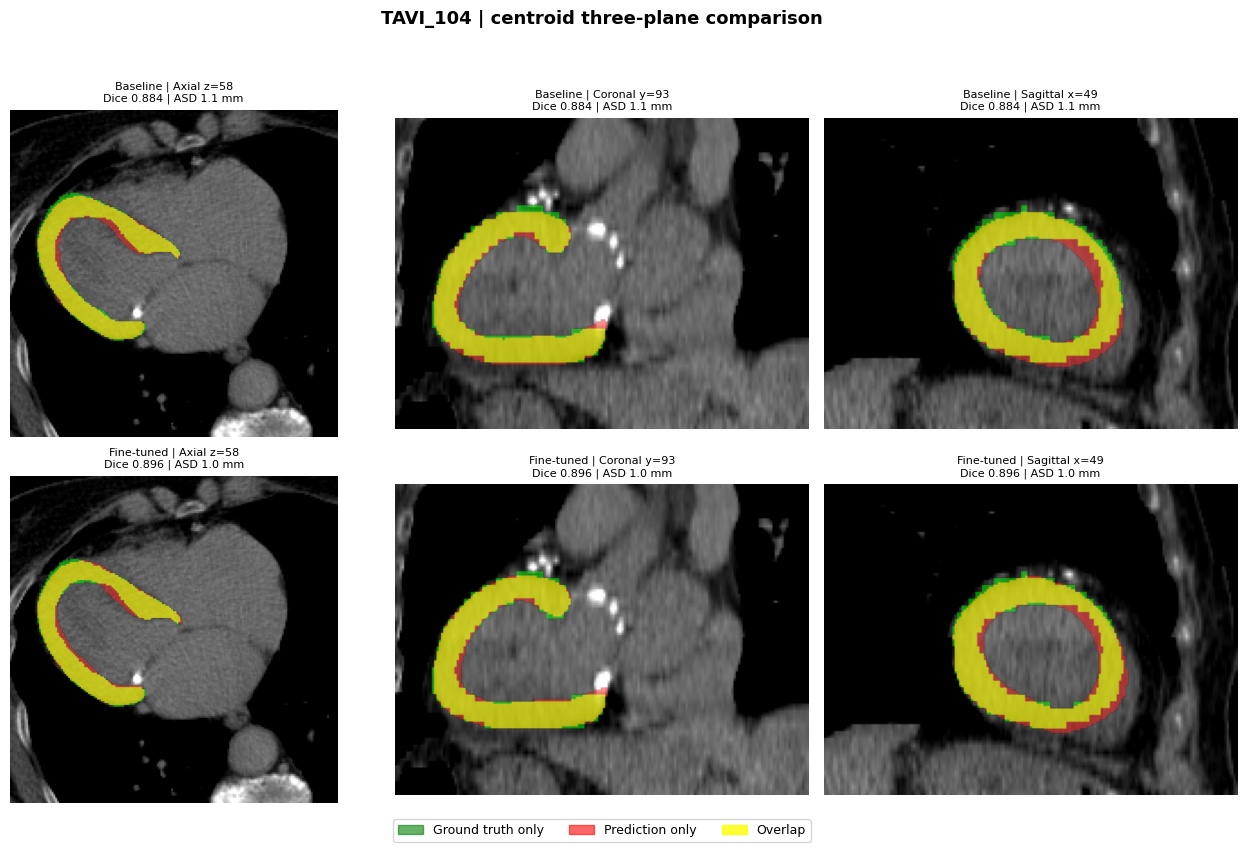

    Saved to /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_104
    Baseline: Dice 0.884 | Fine-tuned: Dice 0.896

[3/46] Processing TAVI_177
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    Baseline inference ...
    Fine-tuned inferen

In [11]:
comparison_models, model_metadata = load_comparison_models(MODEL_SPECS)
all_metric_rows = []
patient_output_rows = []

for patient_index, patient_case in enumerate(selected_cases, start=1):
    patient_id = patient_case["name"]
    patient_dir = COMPARISON_OUTPUT_DIR / patient_id
    patient_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n[{patient_index}/{len(selected_cases)}] Processing {patient_id}")
    copy_slicer_inputs(patient_case, patient_dir)
    ct_vol, gt_mask = load_preprocessed_patient(patient_case)
    model_results = run_models_for_patient(patient_case, comparison_models, patient_dir)

    metrics_by_model = {}
    per_patient_rows = []
    for spec in MODEL_SPECS:
        model_name = spec["name"]
        metric_raw = segmentation_metrics(model_results[model_name]["pred_mask_raw"], gt_mask, TARGET_SPACING)
        metric = segmentation_metrics(model_results[model_name]["pred_mask"], gt_mask, TARGET_SPACING)
        metrics_by_model[model_name] = metric

        row = {
            "fold": FOLD_INDEX,
            "patient_id": patient_id,
            "model": model_name,
            "model_label": spec["label"],
            "checkpoint": model_metadata[model_name]["checkpoint"],
            "checkpoint_state": model_metadata[model_name]["state_key"],
            "checkpoint_step": model_metadata[model_name]["step"],
            "checkpoint_best_dice": model_metadata[model_name]["best_dice"],
            "checkpoint_loss_name": model_metadata[model_name]["loss_name"],
            "preprocessed_shape": "x".join(map(str, gt_mask.shape)),
            "original_prediction_shape": "x".join(map(str, model_results[model_name]["pred_original_shape"])),
            "prediction_path": str(model_results[model_name]["prediction_path"]),
            "raw_dice": metric_raw["dice"],
            "raw_hd95_mm": metric_raw["hd95_mm"],
            "raw_asd_mm": metric_raw["asd_mm"],
            "raw_pred_volume_ml": metric_raw["pred_volume_ml"],
            **metric,
        }
        per_patient_rows.append(row)
        all_metric_rows.append(row)

    patient_metrics_df = pd.DataFrame(per_patient_rows)
    metrics_path = patient_dir / "metrics.csv"
    patient_metrics_df.to_csv(metrics_path, index=False)

    show_figures = patient_index <= DISPLAY_FIRST_N_PATIENTS
    slice_figure = save_slice_percentage_figure(
        patient_id, ct_vol, gt_mask, model_results, metrics_by_model, patient_dir, show=show_figures
    )
    three_plane_figure = save_three_plane_figure(
        patient_id, ct_vol, gt_mask, model_results, metrics_by_model, patient_dir, show=show_figures
    )

    patient_output_rows.append({
        "patient_id": patient_id,
        "patient_dir": str(patient_dir),
        "volume": str(patient_dir / "volume_CT_LATE.nii.gz"),
        "ground_truth": str(patient_dir / "ground_truth_mask.nii.gz"),
        "baseline_segmentation": str(patient_dir / "segmentation_baseline.nii.gz"),
        "finetuned_segmentation": str(patient_dir / "segmentation_finetuned.nii.gz"),
        "slice_figure": str(slice_figure),
        "three_plane_figure": str(three_plane_figure),
        "metrics_csv": str(metrics_path),
    })

    dice_text = " | ".join(
        f"{spec['label']}: Dice {metrics_by_model[spec['name']]['dice']:.3f}"
        for spec in MODEL_SPECS
    )
    print(f"    Saved to {patient_dir}")
    print(f"    {dice_text}")

summary_df = pd.DataFrame(all_metric_rows)
summary_path = COMPARISON_OUTPUT_DIR / "fold0_baseline_vs_finetuned_summary.csv"
summary_df.to_csv(summary_path, index=False)

patient_outputs_df = pd.DataFrame(patient_output_rows)
patient_outputs_path = COMPARISON_OUTPUT_DIR / "patient_output_folders.csv"
patient_outputs_df.to_csv(patient_outputs_path, index=False)

print(f"\nSaved summary metrics to: {summary_path}")
print(f"Saved patient output index to: {patient_outputs_path}")


## 10. Repair Existing Slicer Metadata

Run this cell if the per-patient folders already exist. It rewrites the exported prediction masks with the same affine, spacing, and qform/sform metadata as `volume_CT_LATE.nii.gz`, so they overlay correctly in 3D Slicer.


In [12]:
def repair_existing_slicer_masks(output_root=COMPARISON_OUTPUT_DIR):
    output_root = Path(output_root)
    repaired = []
    missing = []

    for patient_dir in sorted(path for path in output_root.iterdir() if path.is_dir()):
        reference_path = patient_dir / "volume_CT_LATE.nii.gz"
        if not reference_path.exists():
            missing.append(str(reference_path))
            continue

        for mask_name in ("segmentation_baseline.nii.gz", "segmentation_finetuned.nii.gz"):
            mask_path = patient_dir / mask_name
            if not mask_path.exists():
                missing.append(str(mask_path))
                continue

            mask_img = nib.load(str(mask_path))
            mask_data = np.asanyarray(mask_img.dataobj)
            save_mask_like_reference(mask_data, reference_path, mask_path)
            repaired.append(str(mask_path))

    print(f"Repaired {len(repaired)} prediction masks for 3D Slicer overlay.")
    if missing:
        print(f"Skipped {len(missing)} missing files. First missing paths:")
        print("\n".join(missing[:10]))
    return repaired


repaired_slicer_masks = repair_existing_slicer_masks()


Repaired 92 prediction masks for 3D Slicer overlay.


## 11. Summary Table


In [13]:
if "summary_df" not in globals():
    raise RuntimeError("Run the comparison cell before displaying the summary table.")

metric_cols = [
    "fold", "patient_id", "model_label", "raw_dice", "dice", "raw_hd95_mm", "hd95_mm", "raw_asd_mm", "asd_mm",
    "gt_volume_ml", "raw_pred_volume_ml", "pred_volume_ml", "overlap_fraction", "prediction_path",
]

summary_view = summary_df[metric_cols].sort_values(["patient_id", "model_label"]).copy()
display(summary_view.style.hide(axis="index").format({
    "raw_dice": "{:.4f}",
    "dice": "{:.4f}",
    "raw_hd95_mm": "{:.2f}",
    "hd95_mm": "{:.2f}",
    "raw_asd_mm": "{:.2f}",
    "asd_mm": "{:.2f}",
    "gt_volume_ml": "{:.2f}",
    "pred_volume_ml": "{:.2f}",
    "overlap_fraction": "{:.3f}",
}).set_table_styles([
    {"selector": "th", "props": [("background-color", "#263238"), ("color", "white"), ("font-size", "12px")]},
    {"selector": "td", "props": [("font-size", "12px"), ("padding", "5px 8px")]},
]))

pivot = summary_df.pivot(index="patient_id", columns="model", values="dice").reset_index()
if {"baseline", "finetuned"}.issubset(pivot.columns):
    pivot["dice_delta_finetuned_minus_baseline"] = pivot["finetuned"] - pivot["baseline"]
    display(pivot.sort_values("dice_delta_finetuned_minus_baseline", ascending=False).style.hide(axis="index").format({
        "baseline": "{:.4f}",
        "finetuned": "{:.4f}",
        "dice_delta_finetuned_minus_baseline": "{:+.4f}",
    }))

print(f"Per-patient folders: {COMPARISON_OUTPUT_DIR}")
print(f"Summary CSV: {summary_path}")


fold,patient_id,model_label,dice,hd95_mm,asd_mm,gt_volume_ml,pred_volume_ml,overlap_fraction,prediction_path
0,TAVI_014,Baseline,0.8881,3.46,1.13,135.81,134.85,0.885,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_014/segmentation_baseline.nii.gz
0,TAVI_014,Fine-tuned,0.8857,3.61,1.13,135.81,132.98,0.876,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_014/segmentation_finetuned.nii.gz
0,TAVI_024,Baseline,0.8648,3.46,1.15,124.94,138.41,0.911,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_024/segmentation_baseline.nii.gz
0,TAVI_024,Fine-tuned,0.8749,3.16,1.11,124.94,143.13,0.939,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_024/segmentation_finetuned.nii.gz
0,TAVI_029,Baseline,0.8859,3.00,2.69,138.79,139.51,0.888,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_029/segmentation_baseline.nii.gz
0,TAVI_029,Fine-tuned,0.8812,3.32,3.00,138.79,151.45,0.921,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_029/segmentation_finetuned.nii.gz
0,TAVI_038,Baseline,0.9086,2.24,1.36,128.32,120.43,0.881,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_038/segmentation_baseline.nii.gz
0,TAVI_038,Fine-tuned,0.8713,92.27,9.35,128.32,132.91,0.887,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_038/segmentation_finetuned.nii.gz
0,TAVI_040,Baseline,0.8216,4.58,1.61,106.50,92.75,0.769,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_040/segmentation_baseline.nii.gz
0,TAVI_040,Fine-tuned,0.8224,4.90,1.64,106.50,94.51,0.776,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/TAVI_040/segmentation_finetuned.nii.gz


patient_id,baseline,finetuned,dice_delta_finetuned_minus_baseline
TAVI_081,0.8639,0.8899,+0.0260
TAVI_287,0.8725,0.8966,+0.0240
TAVI_283,0.8419,0.8590,+0.0171
TAVI_301,0.8569,0.8714,+0.0145
TAVI_104,0.8837,0.8961,+0.0124
TAVI_364,0.8180,0.8288,+0.0108
TAVI_118,0.8810,0.8916,+0.0105
TAVI_024,0.8648,0.8749,+0.0101
TAVI_099,0.8880,0.8979,+0.0099
TAVI_296,0.8605,0.8687,+0.0081


Per-patient folders: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned
Summary CSV: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/fold0_baseline_vs_finetuned/fold0_baseline_vs_finetuned_summary.csv


## 12. (Optional) Unmount


In [14]:
if "mount_context" in globals() and mount_context is not None:
    mount_context.stop()
    print("Azure mount released.")
else:
    print("No Azure mount active.")


No Azure mount active.
